In [ ]:
import os
import joblib
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [5]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

relaxed_param_bounds = {
    "fts": [-200.0, 200.0],
    "t": [1, 200.0],
    "ampc": [0.01, 1.0],
    'ampm': [-10.0, 10.0],
    "ampg": [-10, 10.0],
    "ampw": [0.0, 1.0],
    "d": [0, 200.0],
    "inh_d": [0, 100.0],
    "inh_w": [-10.0, 10.0],
}

In [6]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [7]:
P = joblib.load(
    os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl')
)

In [8]:
sgcc = SGCCircuit(param_bounds, enforce_permutation=P)

In [9]:
sgcc.load_saved_parameters(optimized_model['final_epoch_params'])

In [10]:
def renorm(sgcc, newbounds):

    dlgn_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[:-2]
    dlgn_lower = tf.reshape(dlgn_bounds[:,0], [1,1,1,-1,1,1])
    dlgn_upper = tf.reshape(dlgn_bounds[:,1], [1,1,1,-1,1,1])

    v1_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[-2:]
    v1_lower = tf.reshape(v1_bounds[:,0], [1,1,1,-1,1,1])
    v1_upper = tf.reshape(v1_bounds[:,1], [1,1,1,-1,1,1])

    params = {
        'dLGN_params': 
            sgcc.variable_transformer(sgcc.params['dLGN_params'], dlgn_lower, dlgn_upper, 'normalize')
        ,
        'V1_params': sgcc.variable_transformer(sgcc.params['V1_params'], v1_lower, v1_upper, 'normalize')
    }

    return params

In [11]:
renormed_params = renorm(sgcc, relaxed_param_bounds)

In [12]:
model = SGCCircuit(relaxed_param_bounds, identify=False)
model.load_saved_parameters(renormed_params)

In [13]:
loss_decay = optimized_model['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 710, loss = 0.06439208984375


In [ ]:
# optimizer = Optimize(sgcc, 1, 0)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000001F83426DD30>


In [15]:
# ## V1 parameter sweep

# v1_landscapes = np.zeros((2,1,2,100))
# for param, key in enumerate(list(relaxed_param_bounds.keys())[7:]):
#     val = relaxed_param_bounds[key]
#     domain = np.linspace(val[0],val[1], 100).astype(np.float32)
#     for v1 in range(2):
#         landscape = np.zeros(100)
#         for step, v in enumerate(domain):
#             model = SGCCircuit(relaxed_param_bounds, identify=False)
#             model.load_saved_parameters(renormed_params)
#             model.set_parameter(
#                 'V1',
#                 np.argsort(last_epoch)[:1000],
#                 [], [v1],
#                 key,
#                 v
#             )
#             Y_pred = model.predict(X)
#             landscape[step] = optimizer.mse(Y_pred, Y_true).numpy().mean()
#         v1_landscapes[v1, 0, param] = landscape

In [16]:
# ## do the parameter sweep

# unit = 1
# dlgn_landscapes = np.zeros((2,3,7,100))
# for param, key in enumerate(list(relaxed_param_bounds.keys())[:7]):
#     val = relaxed_param_bounds[key]
#     domain = np.linspace(val[0],val[1], 100).astype(np.float32)
#     for dlgn in range(3):
#         for v1 in range(2):
#             landscape = np.zeros(100)
#             for step, v in enumerate(domain):
#                 model = SGCCircuit(relaxed_param_bounds, identify=False)
#                 model.load_saved_parameters(renormed_params)
#                 model.set_parameter(
#                     'dLGN',
#                     np.argsort(last_epoch)[:1000],
#                     [dlgn], [v1],
#                     key,
#                     v
#                 )
#                 Y_pred = model.predict(X)
#                 landscape[step] = optimizer.mse(Y_pred, Y_true).numpy().mean()
#             dlgn_landscapes[v1, dlgn, param] = landscape

In [17]:
# np.save('v1_landscapes.npy', v1_landscapes)
# np.save('dlgn_landscapes.npy', dlgn_landscapes)

In [ ]:
v1_landscapes = np.load(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_landscapes.npy'))
dlgn_landscapes = np.load(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'dlgn_landscapes.npy'))

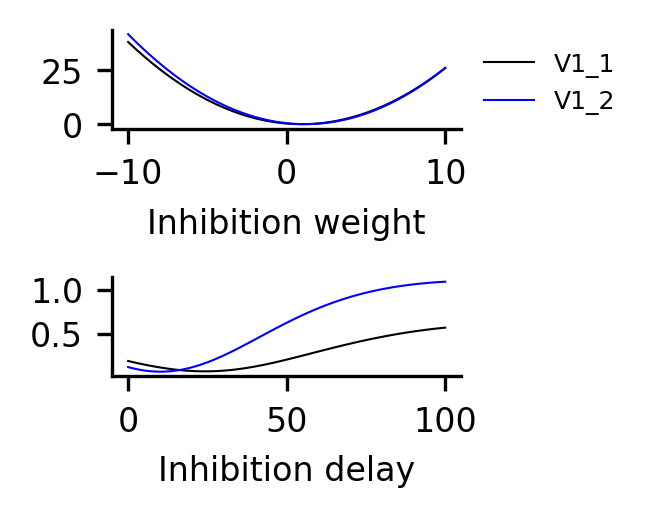

In [ ]:
fig, ax = plt.subplots(2,1, figsize = (1.5, 1.5))

colors = ['black', 'blue']
for i in range(2):
    i_ = np.abs(i-1)
    for u in range(2):
        x = np.linspace(
            list(relaxed_param_bounds.values())[-1-i][0],
            list(relaxed_param_bounds.values())[-1-i][1],
            100
        )
        y = y = v1_landscapes[u,0,i_]

        ax[i].plot(x,y, label = f'V1_{u+1}', linewidth = linewidth, color = colors[u])
        #ax[i].set_yticks(np.arange(0, 1.5, 0.5))
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(labelsize = fontsize)

ax[0].set_xlabel('Inhibition weight', fontsize = fontsize)
ax[1].set_xlabel('Inhibition delay', fontsize = fontsize)
ax[0].legend(fontsize = 6, frameon = False, bbox_to_anchor = (1,1))
fig.subplots_adjust(hspace=1.5)

# figname = 'V1_loss_surface_no_norm.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

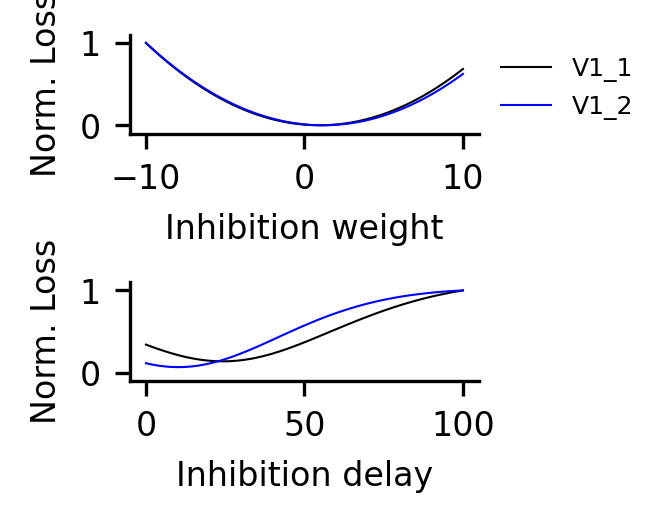

In [60]:
fig, ax = plt.subplots(2,1, figsize = (1.5, 1.5))
colors = ['black', 'blue']
for i in range(2):
    i_ = np.abs(i-1)
    for u in range(2):
        x = np.linspace(
            list(relaxed_param_bounds.values())[-1-i][0],
            list(relaxed_param_bounds.values())[-1-i][1],
            100
        )
        y = y = v1_landscapes[u,0,i_]
        y = y/y.max()

        ax[i].plot(x,y, label = f'V1_{u+1}', linewidth = linewidth, color = colors[u])
        ax[i].set_ylabel("Norm. Loss", fontsize = fontsize)
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(labelsize = fontsize)
        ax[i].set_ylim(-0.1,1.1)

ax[0].set_xlabel('Inhibition weight', fontsize = fontsize)
ax[1].set_xlabel('Inhibition delay', fontsize = fontsize)
ax[0].legend(fontsize = 6, frameon = False, bbox_to_anchor = (1,1))
fig.subplots_adjust(hspace=1.5)
#plt.suptitle("Distribution of V1 parameters post-optimization", fontsize = fontsize, x = 0.525, y = 1.05)

# figname = 'V1_loss_surface.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

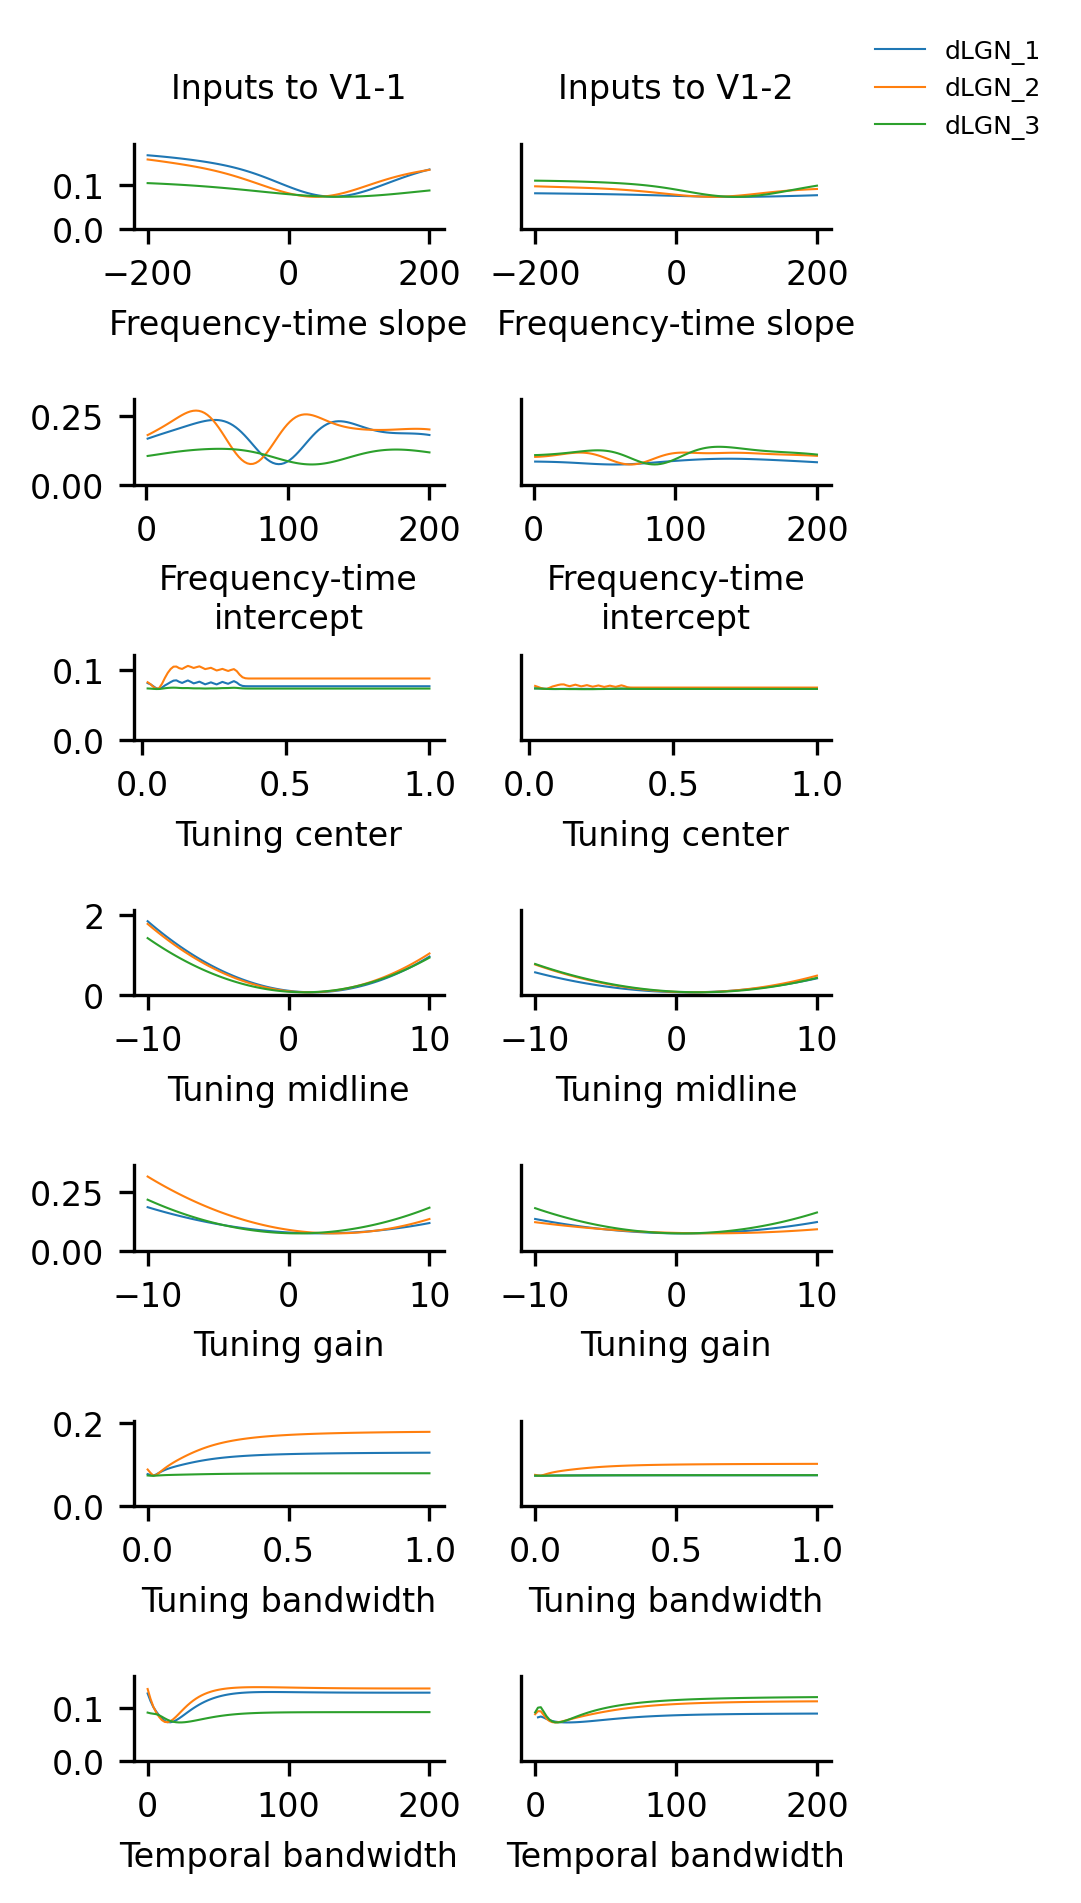

In [ ]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]\

for row in range(7):
    ymax = []
    ymin = []
    for i in range(3):
        for u in range(2):
            
            key = list(relaxed_param_bounds.keys())[row]
            x = np.linspace(
                relaxed_param_bounds[key][0],
                relaxed_param_bounds[key][1], 
                100
            )

            y = dlgn_landscapes[u,i,row]
            ymax.append(y[~np.isnan(y)].max())
            ymin.append(y[~np.isnan(y)].min())

            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    for u in range(2):
        ax[row, u].set_ylim(
            0, 
            np.max(ymax) + np.max(ymax)*0.15
        )
        ax[row, 1].set_yticks([])
        #ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)

# figname = 'dLGN_loss_surface_no_norm.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

Text(0.5, 1.25, 'Inputs to V1-2')

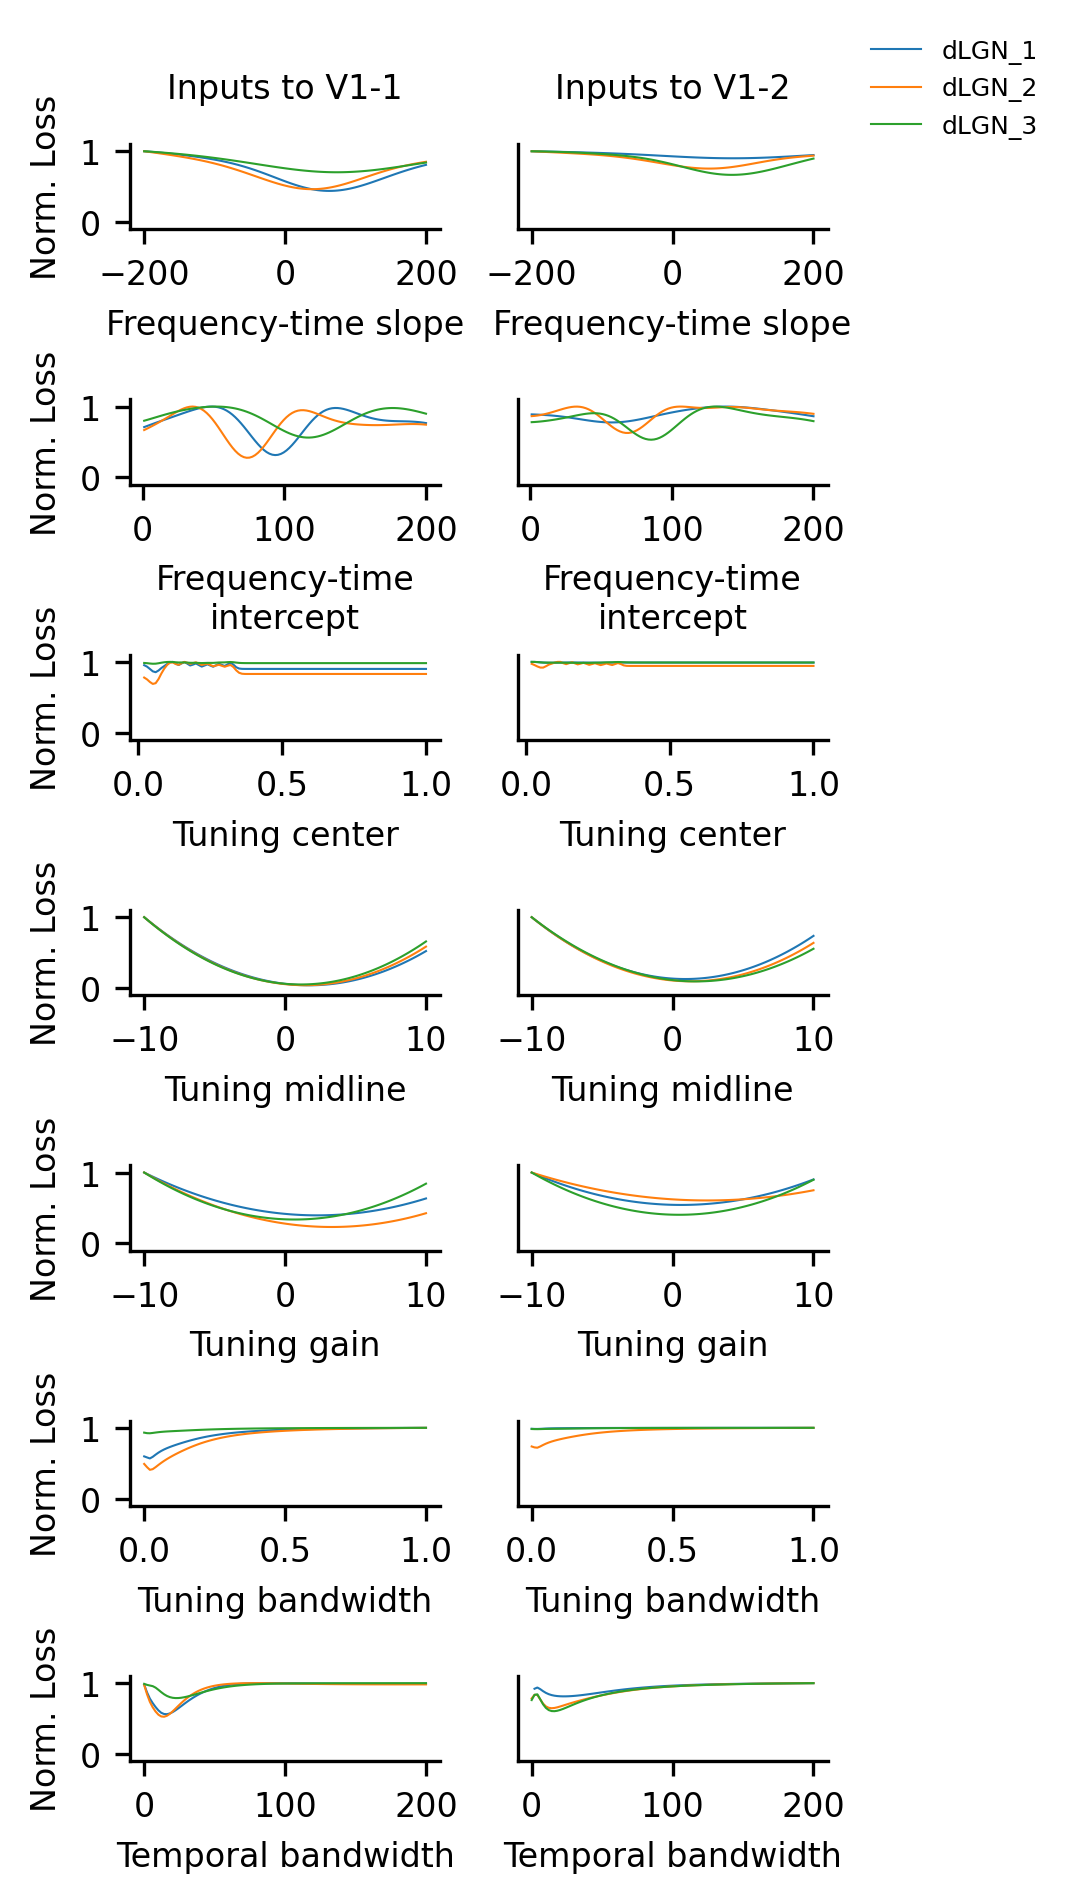

In [64]:
## Loss values are max-normalized for each set of 3 afferents to aid in visualization

fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]\

for row in range(7):
    ymax = []
    ymin = []
    for i in range(3):
        for u in range(2):
            
            key = list(relaxed_param_bounds.keys())[row]
            x = np.linspace(
                relaxed_param_bounds[key][0],
                relaxed_param_bounds[key][1], 
                100
            )

            y = dlgn_landscapes[u,i,row]/y[~np.isnan(y)].max()
            y = y/y[~np.isnan(y)].max()
            ymax.append(y[~np.isnan(y)].max())
            ymin.append(y[~np.isnan(y)].min())
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("Norm. Loss", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(
            -0.1, 
            1.1
        )
        ax[row, 1].set_yticks([])
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)

# figname = 'dLGN_loss_surface.svg'
# savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [55]:
imp_v1 = np.zeros((1,2,1,2,1,1))
for i in range(2):
    for u in range(2):
        x = np.linspace(
            list(relaxed_param_bounds.values())[7+i][0],
            list(relaxed_param_bounds.values())[7+i][1],
            100
        )
        imp_v1[0,u,0,i,0,0] = x[np.where(v1_landscapes[u,0,i] == np.nanmin(v1_landscapes[u,0,i]))[0][0]]

In [56]:
imp_dlgn = np.zeros((1,2,3,7,1,1))
for row in range(7):
    for i in range(3):
        for u in range(2):
            
            key = list(relaxed_param_bounds.keys())[row]
            x = np.linspace(
                relaxed_param_bounds[key][0],
                relaxed_param_bounds[key][1], 
                100
            )

            y = dlgn_landscapes[u,i,row]
            imp_dlgn[0,u,i,row,0,0] = x[np.where(y == np.nanmin(y))[0][0]]

In [57]:
def renorm(v1, dlgn, newbounds):

    dlgn_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[:-2]
    dlgn_lower = tf.reshape(dlgn_bounds[:,0], [1,1,1,-1,1,1])
    dlgn_upper = tf.reshape(dlgn_bounds[:,1], [1,1,1,-1,1,1])

    v1_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[-2:]
    v1_lower = tf.reshape(v1_bounds[:,0], [1,1,1,-1,1,1])
    v1_upper = tf.reshape(v1_bounds[:,1], [1,1,1,-1,1,1])

    params = {
        'dLGN_params': sgcc.inverse_dlgn_property(
            sgcc.variable_transformer(dlgn, dlgn_lower, dlgn_upper, 'normalize')
        ),
        'V1_params': sgcc.variable_transformer(v1, v1_lower, v1_upper, 'normalize')
    }

    return params

In [ ]:
# pfs = renorm(imp_v1, imp_dlgn, relaxed_param_bounds)

In [ ]:
# with open(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'parameters_from_sweep.pkl'), 'wb') as f:
#     pickle.dump(pfs, f)